## T5 Encoder Injection

### Check CUDA is Available

In [2]:
# check CUDA available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device count: 2
Current device: 0
Device name: NVIDIA GeForce RTX 2080 Ti


### Import Necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import T5Tokenizer, T5ForConditionalGeneration # huggingface T5 model + tokenizer
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import torchmetrics
from t5injection import MultitaskModel, MultitaskDataset, create_weighted_sampler, evaluate_with_sampling, setup_training_pipeline, train, train_and_validate_model_with_meteor_rouge, train_and_validate_model_with_meteor_stopping, METEOREarlyStopping, display_generated_texts, print_test_evaluation, compute_rougeL
from sklearn.model_selection import train_test_split
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score
import nltk
import random
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

### Set Random Seed for Reproducibility

In [4]:
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

### Import Dataset

In [5]:
mwr_df = pd.read_csv('mwr.csv')

In [6]:
print(mwr_df.columns)

Index(['Examination ID', 'Conclusion', 'r:Th', 'Weight', 'Height',
       'Ambient temperature', 'r:AgeInYears', 'Mammary diameter', 'Cycle',
       'Day from the first day', 'Hormonal medications',
       'Cancer family history', 'Breast operations', 'Num of pregnancies',
       'R1 int', 'L1 int', 'R2 int', 'L2 int', 'R3 int', 'L3 int', 'R4 int',
       'L4 int', 'R5 int', 'L5 int', 'R6 int', 'L6 int', 'R7 int', 'L7 int',
       'R8 int', 'L8 int', 'R9 int', 'L9 int', 'T1 int', 'T2 int', 'R0 int',
       'L0 int', 'R1 sk', 'L1 sk', 'R2 sk', 'L2 sk', 'R3 sk', 'L3 sk', 'R4 sk',
       'L4 sk', 'R5 sk', 'L5 sk', 'R6 sk', 'L6 sk', 'R7 sk', 'L7 sk', 'R8 sk',
       'L8 sk', 'R9 sk', 'L9 sk', 'T1 sk', 'T2 sk', 'R0 sk', 'L0 sk',
       'Conclusion (Tr)', 'y_binary'],
      dtype='object')


### Extract Features

In [7]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df.columns if col.endswith('int') or col.endswith('sk')]
mwr_df['features'] = mwr_df[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df['class_label'] = mwr_df['y_binary'].astype(int)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

### Split Data into Test and Train

In [8]:
# 70% training, 15% validation, 15% testing

# Stratified split on 'r:Th' column
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df['r:Th']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['r:Th']
)

In [9]:
# check class distribution
print(mwr_df['class_label'].value_counts(normalize=True))
#print(train_df['synthetic_description'].value_counts())

class_label
1    0.758215
0    0.241785
Name: proportion, dtype: float64


## T5 Injection and Full Text

### Initialise Model

In [10]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = setup_training_pipeline(
    df_train=train_df,
    df_val=val_df,
    df_test=test_df,
    multitask_model_class=MultitaskModel,
    multitask_dataset_class=MultitaskDataset,
    text_mode='full'
)

Loading tokenizer...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Creating datasets with text_mode='full'...
Creating dataloaders...
Setting up device...
Initializing model...
Initial weights - CLF: 0.1, GEN: 10
Moving model to device...
Setting up optimizer...
After .to(device) - CLF: 0.1, GEN: 10
✓ Setup complete with text_mode='full'!



### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 18.7219
Classification loss: 0.6357
Generation loss: 1.8658
Weighted gen loss: 18.658307
Validation loss: 10.6839
Validation metrics:
  Accuracy     : 0.7050
  F1-Score     : 0.7025
  Sensitivity  : 0.8133
  Specificity  : 0.3660
  AUC-ROC      : 0.6683

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4315
  ✓ New best METEOR: 0.4315
  ROUGE-L F1   : 0.4350
  ✓ New best ROUGE-L F1: 0.4350
✓ New best accuracy: 0.7050
✓ New best F1: 0.7025
✓ New best AUC-ROC: 0.6683

Epoch 2/50
Training loss: 11.3106
Classification loss: 0.5602
Generation loss: 1.1255
Weighted gen loss: 11.254609
Validation loss: 9.2290
Validation metrics:
  Accuracy     : 0.7161
  F1-Score     : 0.7175
  Sensitivity  : 0.8078
  Specificity  : 0.4287
  AUC-ROC      : 0.6988

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.3981
  ROUGE-L F1   : 0.3986
✓ New best AUC-ROC: 0.7827

Epoch 17/50
Training loss: 7.2771
Classification loss: 0.4753
Generation loss: 0.7230
Weighted gen loss: 7.229537
Validation loss: 6.8199
Validation metrics:
  Accuracy     : 0.7599
  F1-Score     : 0.7674
  Sensitivity  : 0.8071
  Specificity  : 0.6123
  AUC-ROC      : 0.7952

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3859
  ROUGE-L F1   : 0.3920
✓ New best F1: 0.7674
✓ New best AUC-ROC: 0.7952

Epoch 18/50
Training loss: 7.2002
Classification loss: 0.4733
Generation loss: 0.7153
Weighted gen loss: 7.152900
Validation loss: 6.6931
Validation metrics:
  Accuracy     : 0.7594
  F1-Score     : 0.7627
  Sensitivity  : 0.8274
  Specificity  : 0.5462
  AUC-ROC      : 0.7890

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples

Training loss: 6.4529
Classification loss: 0.4457
Generation loss: 0.6408
Weighted gen loss: 6.408334
Validation loss: 6.1597
Validation metrics:
  Accuracy     : 0.7759
  F1-Score     : 0.7785
  Sensitivity  : 0.8409
  Specificity  : 0.5724
  AUC-ROC      : 0.8143

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3865
  ROUGE-L F1   : 0.3906
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.4268
Classification loss: 0.4474
Generation loss: 0.6382
Weighted gen loss: 6.382092
Validation loss: 6.1468
Validation metrics:
  Accuracy     : 0.7688
  F1-Score     : 0.7758
  Sensitivity  : 0.8136
  Specificity  : 0.6283
  AUC-ROC      : 0.8139

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4006
  ROUGE-L F1   : 0.4049

Epoch 35/50
Training loss: 6.3996
Class

  METEOR Score : 0.4107
  ROUGE-L F1   : 0.4134

Epoch 50/50
Training loss: 6.0266
Classification loss: 0.4310
Generation loss: 0.5983
Weighted gen loss: 5.983455
Validation loss: 5.9929
Validation metrics:
  Accuracy     : 0.7726
  F1-Score     : 0.7787
  Sensitivity  : 0.8213
  Specificity  : 0.6203
  AUC-ROC      : 0.8202

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4200
  ROUGE-L F1   : 0.4178


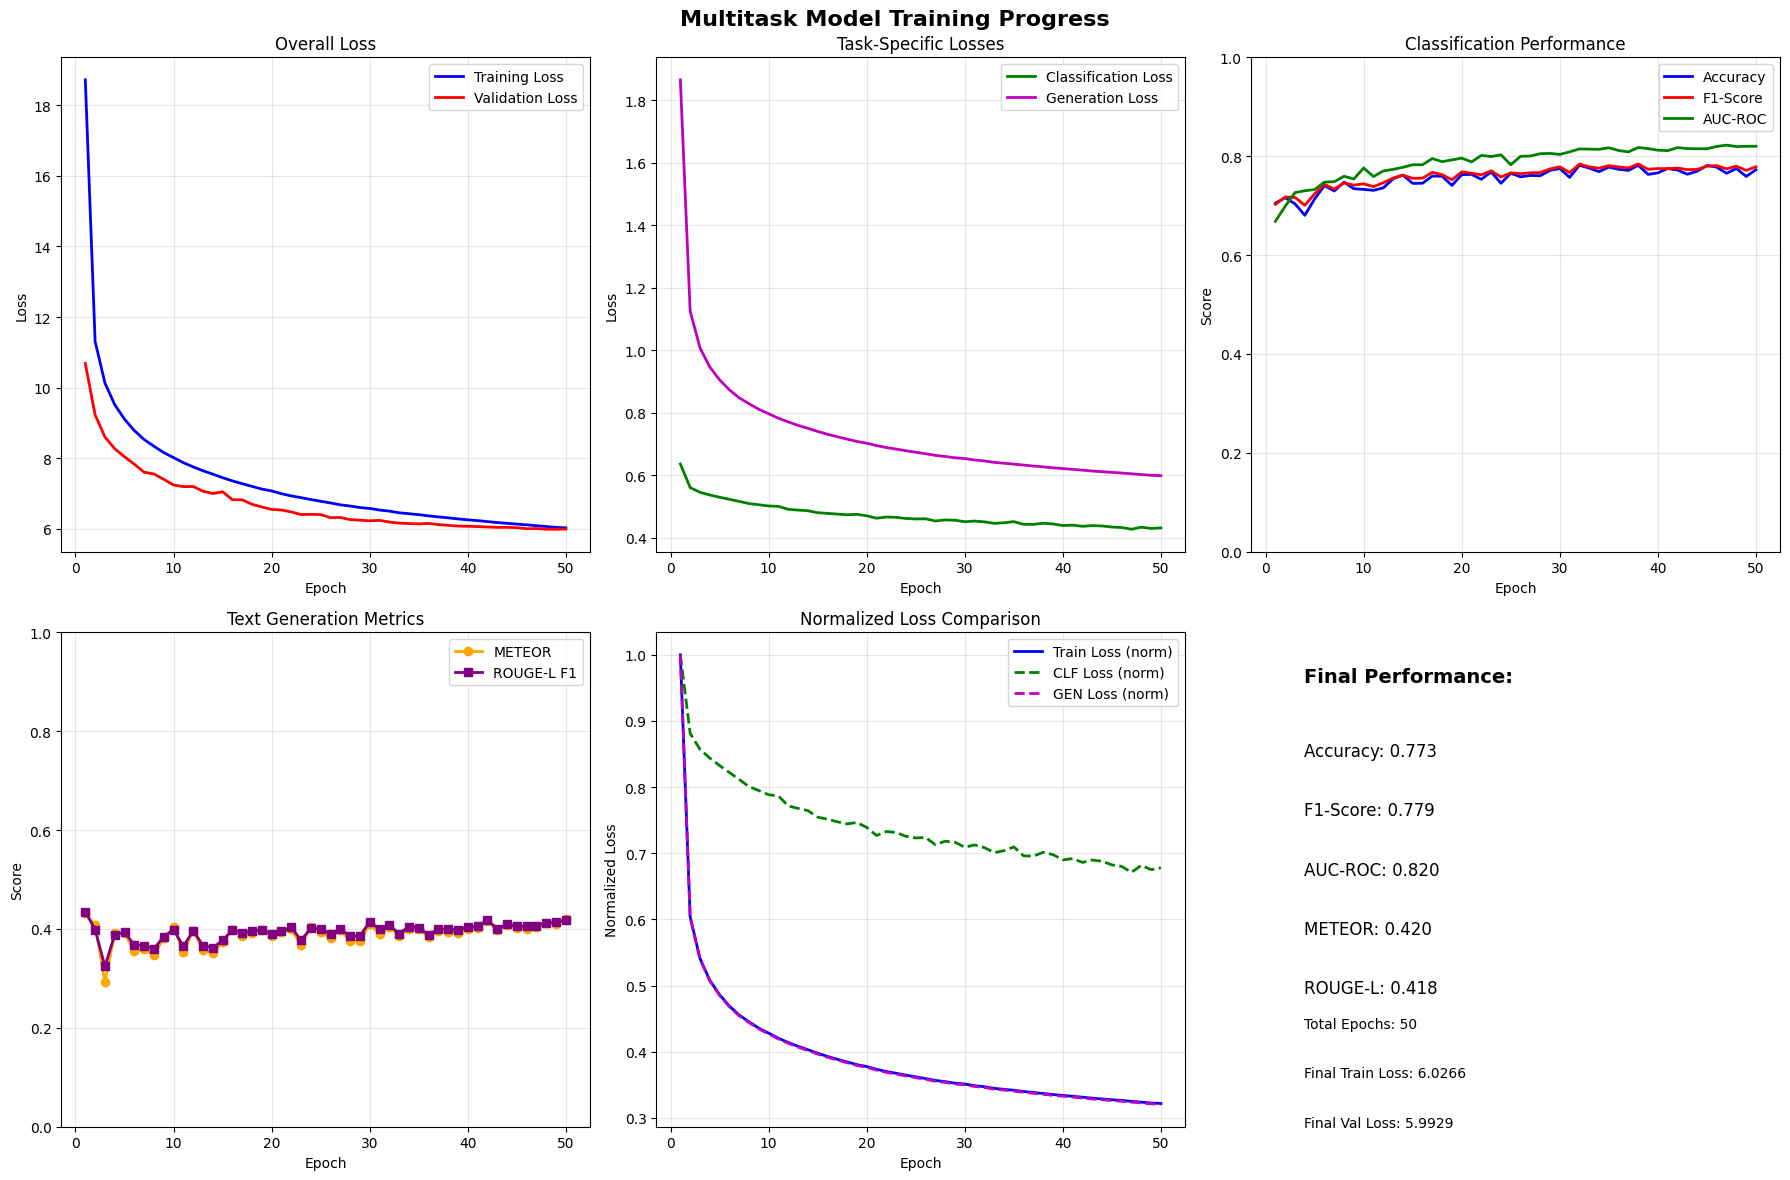


TRAINING SUMMARY
Best Accuracy: 0.7817
Best F1-Score: 0.7843
Best AUC-ROC: 0.8224
Best METEOR: 0.4315
Best ROUGE-L: 0.4350


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 5.9470
Classification metrics (all 3625 samples):
  Accuracy     : 0.7881
  F1-Score     : 0.7929
  Sensitivity  : 0.8367
  Specificity  : 0.6358
  AUC-ROC      : 0.8401

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4181
  METEOR       : 0.4191

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan in one year (May 2010). In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. I advise regular self-examinations, regular recommended clinical examinations by a specialist doctor, and a mammogram based on their opinion, as well as a repeat breast scan measurement in one year. In
Reference :

## T5 Injection and Minimal Text

### Initialise Model

In [10]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = setup_training_pipeline(
    df_train=train_df,
    df_val=val_df,
    df_test=test_df,
    multitask_model_class=MultitaskModel,
    multitask_dataset_class=MultitaskDataset,
    text_mode='minimal'
)

Loading tokenizer...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Creating datasets with text_mode='minimal'...
Creating dataloaders...
Setting up device...
Initializing model...
Initial weights - CLF: 0.1, GEN: 10
Moving model to device...
Setting up optimizer...
After .to(device) - CLF: 0.1, GEN: 10
✓ Setup complete with text_mode='minimal'!



### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 20.0838
Classification loss: 0.6315
Generation loss: 2.0021
Weighted gen loss: 20.020656
Validation loss: 10.8944
Validation metrics:
  Accuracy     : 0.7086
  F1-Score     : 0.7115
  Sensitivity  : 0.7980
  Specificity  : 0.4287
  AUC-ROC      : 0.6858

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4062
  ✓ New best METEOR: 0.4062
  ROUGE-L F1   : 0.4225
  ✓ New best ROUGE-L F1: 0.4225
✓ New best accuracy: 0.7086
✓ New best F1: 0.7115
✓ New best AUC-ROC: 0.6858

Epoch 2/50
Training loss: 11.7019
Classification loss: 0.5612
Generation loss: 1.1646
Weighted gen loss: 11.645824
Validation loss: 9.4652
Validation metrics:
  Accuracy     : 0.7290
  F1-Score     : 0.7180
  Sensitivity  : 0.8537
  Specificity  : 0.3387
  AUC-ROC      : 0.7063

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples

Computing text metrics on 3624 samples...
  METEOR Score : 0.2461
  ROUGE-L F1   : 0.2735

Epoch 17/50
Training loss: 7.5715
Classification loss: 0.4741
Generation loss: 0.7524
Weighted gen loss: 7.524124
Validation loss: 7.0861
Validation metrics:
  Accuracy     : 0.7583
  F1-Score     : 0.7626
  Sensitivity  : 0.8224
  Specificity  : 0.5576
  AUC-ROC      : 0.7902

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.2461
  ROUGE-L F1   : 0.2735
✓ New best F1: 0.7626
✓ New best AUC-ROC: 0.7902

Epoch 18/50
Training loss: 7.4978
Classification loss: 0.4751
Generation loss: 0.7450
Weighted gen loss: 7.450308
Validation loss: 6.9916
Validation metrics:
  Accuracy     : 0.7671
  F1-Score     : 0.7600
  Sensitivity  : 0.8715
  Specificity  : 0.4401
  AUC-ROC      : 0.7889

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on

  METEOR Score : 0.2461
  ROUGE-L F1   : 0.2731
✓ New best accuracy: 0.7870
✓ New best F1: 0.7862
✓ New best AUC-ROC: 0.8149

Epoch 33/50
Training loss: 6.7163
Classification loss: 0.4494
Generation loss: 0.6671
Weighted gen loss: 6.671328
Validation loss: 6.3493
Validation metrics:
  Accuracy     : 0.7762
  F1-Score     : 0.7727
  Sensitivity  : 0.8660
  Specificity  : 0.4949
  AUC-ROC      : 0.8106

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.2461
  ROUGE-L F1   : 0.2731
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 6.6902
Classification loss: 0.4463
Generation loss: 0.6646
Weighted gen loss: 6.645558
Validation loss: 6.3546
Validation metrics:
  Accuracy     : 0.7643
  F1-Score     : 0.7716
  Sensitivity  : 0.8103
  Specificity  : 0.6203
  AUC-ROC      : 0.8140

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 s

Computing text metrics on 3624 samples...
  METEOR Score : 0.2461
  ROUGE-L F1   : 0.2727

Epoch 50/50
Training loss: 6.2802
Classification loss: 0.4314
Generation loss: 0.6237
Weighted gen loss: 6.237055
Validation loss: 6.1237
Validation metrics:
  Accuracy     : 0.7737
  F1-Score     : 0.7781
  Sensitivity  : 0.8307
  Specificity  : 0.5952
  AUC-ROC      : 0.8188

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4274
  ROUGE-L F1   : 0.4357
  ✓ New best ROUGE-L F1: 0.4357


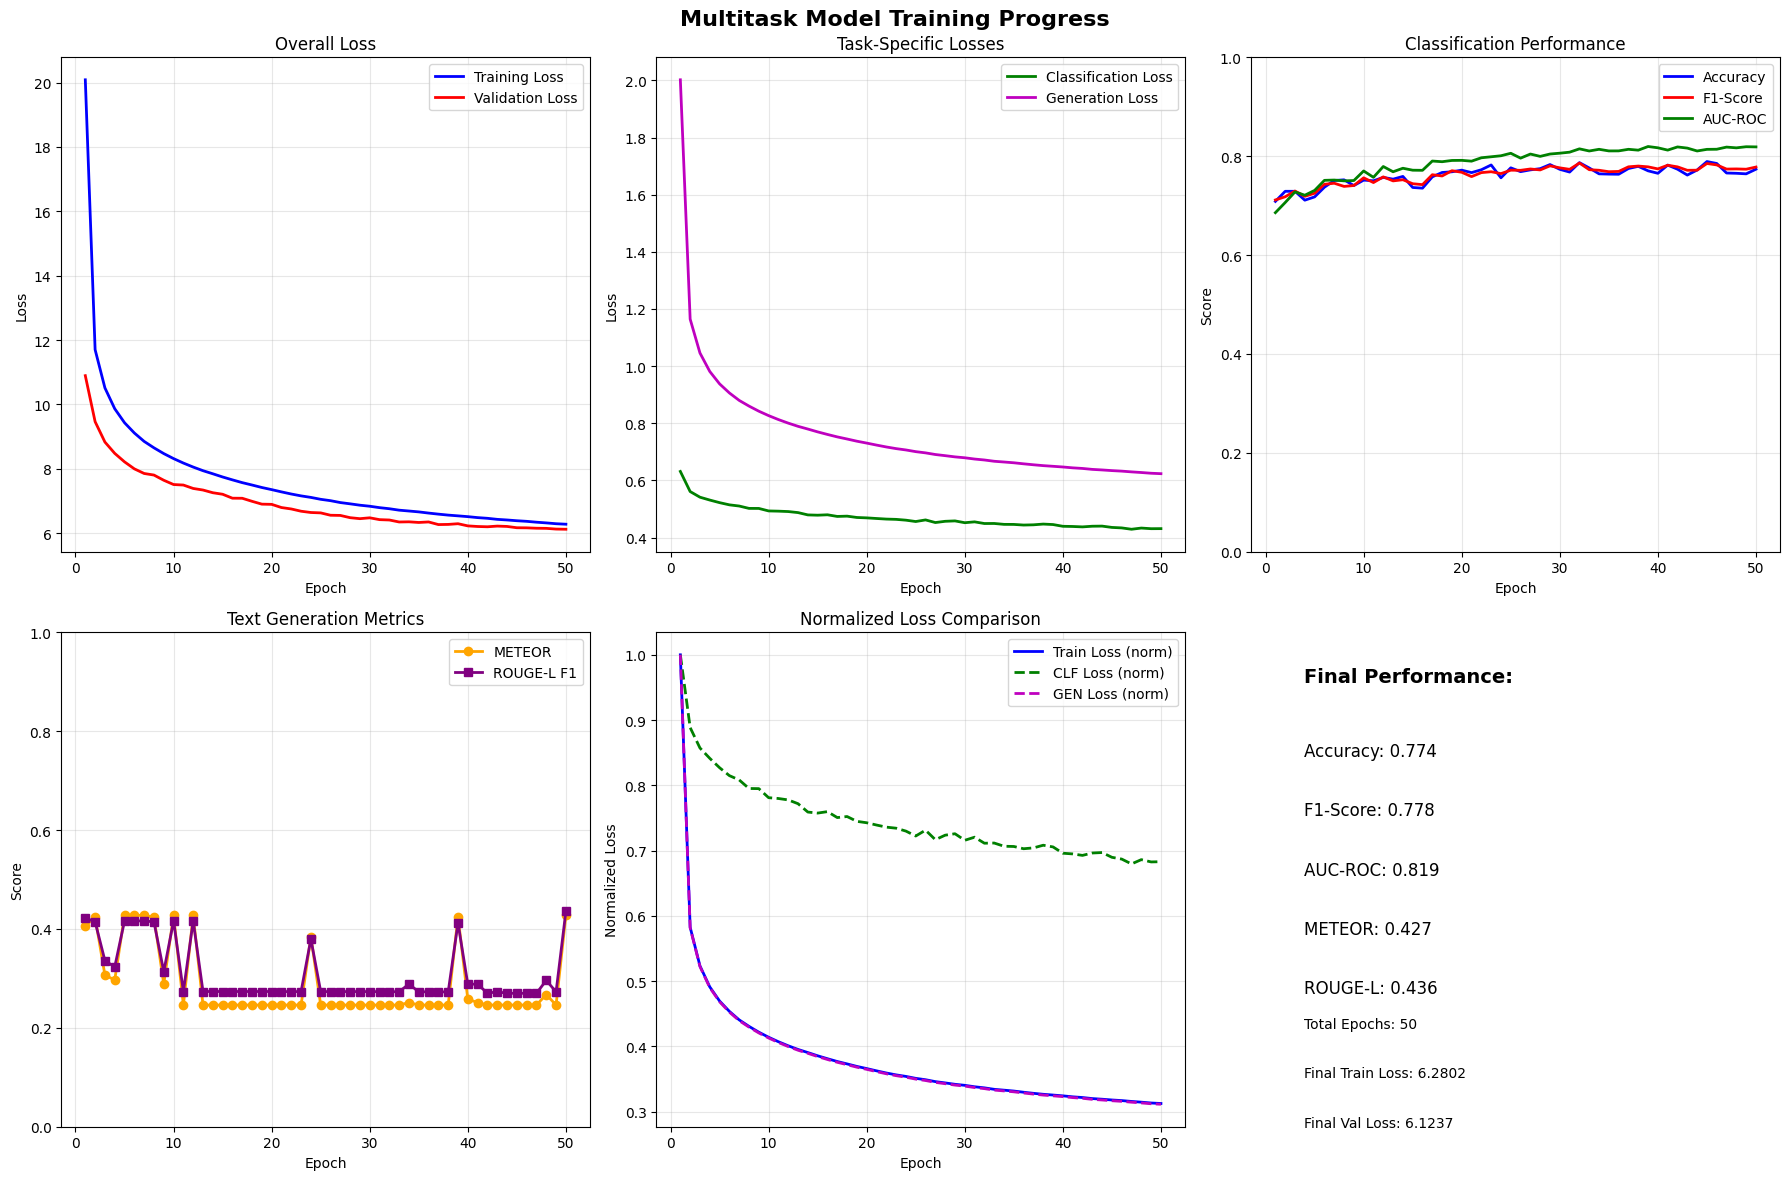


TRAINING SUMMARY
Best Accuracy: 0.7892
Best F1-Score: 0.7862
Best AUC-ROC: 0.8196
Best METEOR: 0.4278
Best ROUGE-L: 0.4357


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.0673
Classification metrics (all 3625 samples):
  Accuracy     : 0.7931
  F1-Score     : 0.7960
  Sensitivity  : 0.8494
  Specificity  : 0.6164
  AUC-ROC      : 0.8371

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4332
  METEOR       : 0.4248

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate signs of locally elevated metabolism in the breast tissue. We recommend regular self-examinations and a follow-up breast scan in one year (November 2011). In case of noticeable, visible changes, discharge, or prolonged pain, we
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate signs of locally elevated metabolism in the breast tissue. We recommend regular self-examinations and a follow-up breast scan in one year (November 2011). In case of noticeable, visible changes, discharge, or prolonged pain, we
Reference : The mea